In [1]:
# ─────────────────────────────────────────────────────────
# PART 1A — DATA QUALITY REPORT
# ─────────────────────────────────────────────────────────

import pandas as pd           # main data handling
import numpy as np            # numerical operations
import ast                    # for parsing stringified lists later
import re                     # for pattern matching (nct_id format checks)
import matplotlib.pyplot as plt  # plotting
import seaborn as sns         # prettier plots
from datetime import datetime # date comparisons

# Display settings, so pandas doesn't cut off columns
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 60)
pd.set_option("display.float_format", "{:.1f}".format)

print("Libraries loaded. Let's diagnose this data.")

Libraries loaded. Let's diagnose this data.


In [2]:
# ─────────────────────────────────────────────────────────
# SECTION 2 — LOAD DATA
# ─────────────────────────────────────────────────────────

# Load the raw Excel file 
df_raw = pd.read_excel("data/SampleDateExtract.xlsx")

# Aworking on a copy so raw data is never touched
df = df_raw.copy()

print(f"   Dataset loaded successfully.")
print(f"   Rows    : {df.shape[0]}")
print(f"   Columns : {df.shape[1]}")

   Dataset loaded successfully.
   Rows    : 1000
   Columns : 18


In [3]:
# ─────────────────────────────────────────────────────────
# SECTION 3 — FIRST LOOK
# ─────────────────────────────────────────────────────────

# Column names and data types
print("COLUMNS & DATA TYPES")
print("=" * 40)
print(df.dtypes)

print("\n\nFIRST 3 ROWS")
print("=" * 40)
df.head(3)

COLUMNS & DATA TYPES
ID-datalake                         int64
nct_id                             object
brief_title                        object
official_title                     object
phase                              object
recruitment_status                 object
start_date                 datetime64[ns]
completion_date            datetime64[ns]
primary_completion_date    datetime64[ns]
enrollment                        float64
enrollment_type                    object
indications                        object
interventions_drugs                object
drugs_datalake                     object
main_technologies                  object
specific_technologies              object
target_names                       object
target_abbreviations               object
dtype: object


FIRST 3 ROWS


,ID-datalake,nct_id,brief_title,official_title,phase,recruitment_status,start_date,completion_date,primary_completion_date,enrollment,enrollment_type,indications,interventions_drugs,drugs_datalake,main_technologies,specific_technologies,target_names,target_abbreviations
0,61690,NCT06669572,Lenvatinib and Pembrolizumab to Treat Patients With Anal...,"A Phase II, Multi-center, Single Arm Trial of Lenvatinib...",PHASE2,NOT_YET_RECRUITING,2026-01-13,2029-03-26,2029-03-26,35.0,ESTIMATED,"['Anorectal Cancer', 'Epithelial Neoplasm']","['Pembrolizumab', 'Lenvatinib']","['B936', 'B261']","[['Antibody'], ['Small Molecule']]","[['Monoclonal Antibody'], ['Small Molecule']]","[['Programmed cell death protein 1'], ['Fibroblast growt...","[['PD-1'], ['FGFR1', 'FGFR2', 'FGFR3', 'FGFR4', 'PDGFRÎ±..."
1,63117,NCT06883552,"An Open-label, Single-arm Clinical Study of Stapokibart ...","An Open-label, Single-arm Clinical Study of Stapokibart ...",PHASE2,NOT_YET_RECRUITING,2025-10-01,2026-10-01,2026-10-01,21.0,ESTIMATED,['Thoracic Neoplasm'],['Tislelizumab'],['B1344'],[['Antibody']],[['Monoclonal Antibody']],[['Programmed cell death protein 1']],[['PD-1']]
2,56177,NCT06366490,Safety and Immunogenicity of Innocell Autologous Cellula...,Phase 1 Study to Assess the Safety and Immunogenicity of...,PHASE1,NOT_YET_RECRUITING,2025-06-30,2026-06-30,2025-12-30,8.0,ESTIMATED,['Ovarian Cancer'],['Innocell'],['B11796'],[['Cancer Vaccine']],[['Whole Tumor Cell Vaccine']],[[]],[[]]


In [4]:
# A closer look at one full row 
print("SAMPLE ROW — FULL DETAIL")
print("=" * 40)
for col in df.columns:
    print(f"\n[{col}]")
    print(f"  {df[col].iloc[0]}")

SAMPLE ROW — FULL DETAIL

[ID-datalake]
  61690

[nct_id]
  NCT06669572

[brief_title]
  Lenvatinib and Pembrolizumab to Treat Patients With Anal or Rectum Cancer That Has Gotten Worse After Initial Treatment

[official_title]
  A Phase II, Multi-center, Single Arm Trial of Lenvatinib Plus Pembrolizumab in Patients With Unresectable Locally Advanced and/or Metastatic Anorectal Squamous Cell Carcinoma (ASCC) After Progression on First Line Chemotherapy.

[phase]
  PHASE2

[recruitment_status]
  NOT_YET_RECRUITING

[start_date]
  2026-01-13 00:00:00

[completion_date]
  2029-03-26 00:00:00

[primary_completion_date]
  2029-03-26 00:00:00

[enrollment]
  35.0

[enrollment_type]
  ESTIMATED

[indications]
  ['Anorectal Cancer', 'Epithelial Neoplasm']

[interventions_drugs]
  ['Pembrolizumab', 'Lenvatinib']

[drugs_datalake]
  ['B936', 'B261']

[main_technologies]
  [['Antibody'], ['Small Molecule']]

[specific_technologies]
  [['Monoclonal Antibody'], ['Small Molecule']]

[target_names]
  

In [5]:
# ─────────────────────────────────────────────────────────
# SECTION 4 — NULL & COMPLETENESS REPORT
# ─────────────────────────────────────────────────────────

# Build a summary table for every column
quality_report = pd.DataFrame({
    "total_values"    : df.shape[0],
    "null_count"      : df.isnull().sum(),
    "completeness_%"  : ((1 - df.isnull().mean()) * 100).round(1),
    "dtype"           : df.dtypes
}).reset_index()

quality_report.columns = ["column", "total_values", "null_count", "completeness_%", "dtype"]

# Flag columns by severity
def flag_severity(pct):
    if pct == 100:
        return "OK"
    elif pct >= 95:
        return "MINOR"
    elif pct >= 80:
        return "WARNING"
    else:
        return "CRITICAL"

quality_report["status"] = quality_report["completeness_%"].apply(flag_severity)

# Sort by completeness so worst columns appear first
quality_report = quality_report.sort_values("completeness_%")

print("NULL & COMPLETENESS REPORT")
print("=" * 60)
print(quality_report.to_string(index=False))

NULL & COMPLETENESS REPORT
                 column  total_values  null_count  completeness_%          dtype  status
        completion_date          1000          52            94.8 datetime64[ns] WARNING
primary_completion_date          1000          51            94.9 datetime64[ns] WARNING
        enrollment_type          1000          44            95.6         object   MINOR
                  phase          1000          40            96.0         object   MINOR
             enrollment          1000          26            97.4        float64   MINOR
         official_title          1000           6            99.4         object   MINOR
             start_date          1000           5            99.5 datetime64[ns]   MINOR
            brief_title          1000           0           100.0         object      OK
     recruitment_status          1000           0           100.0         object      OK
            ID-datalake          1000           0           100.0          int64   

In [6]:
# Summary counts by severity
print("\nSEVERITY SUMMARY")
print("=" * 40)
print(quality_report["status"].value_counts().to_string())

print("\n\nCRITICAL & WARNING COLUMNS")
print("=" * 40)
flagged = quality_report[quality_report["status"].isin(["CRITICAL", "WARNING"])]
for _, row in flagged.iterrows():
    print(f"  {row['column']:<30} {row['null_count']} missing ({row['completeness_%']}% complete)  [{row['status']}]")


SEVERITY SUMMARY
status
OK         11
MINOR       5
WARNING     2


CRITICAL & WARNING COLUMNS
  completion_date                52 missing (94.8% complete)  [WARNING]
  primary_completion_date        51 missing (94.9% complete)  [WARNING]


In [7]:
# What do trials with missing phase look like?
print("TRIALS WITH MISSING PHASE")
print("=" * 60)
missing_phase = df[df["phase"].isnull()][["nct_id", "brief_title", "recruitment_status", "phase"]]
print(f"Total: {len(missing_phase)}")
print()
print(missing_phase.to_string(index=False))

TRIALS WITH MISSING PHASE
Total: 40

     nct_id                                                                                                                                                                                                                   brief_title    recruitment_status phase
NCT06856200                                                                                              A Study of Sirolimus (Albumin-Bound) in Combination With Palbociclib and Fulvestrant for the Treatment of Advanced Breast Cancer            RECRUITING   NaN
NCT06402383                                                                                                              Supporting the National Expansion of HPV-based Cervical Cancer Screening in Tanzania Among Women Living with HIV ACTIVE_NOT_RECRUITING   NaN
NCT06494514                                                       NALIRIFOX Combined With PD-1 Sequential Radiotherapy Versus AG Combined With PD-1 Sequential Radiotherapy as Fi

In [8]:
# Status distribution of trials with missing phase
print("STATUS BREAKDOWN — MISSING PHASE TRIALS")
print("=" * 40)
print(df[df["phase"].isnull()]["recruitment_status"].value_counts().to_string())

print("\n\nKEY FINDING")
print("=" * 40)
print("""
Many trials with missing phase are not standard drug efficacy trials.
They include surgical procedures, anaesthesia studies, and nutritional
interventions that do not follow the Phase 1/2/3 framework.

These trials will be flagged separately and excluded from
phase-based success rate calculations in Part 2.
""")

STATUS BREAKDOWN — MISSING PHASE TRIALS
recruitment_status
COMPLETED                20
RECRUITING                5
UNKNOWN                   5
TERMINATED                4
ACTIVE_NOT_RECRUITING     3
WITHDRAWN                 2
NOT_YET_RECRUITING        1


KEY FINDING

Many trials with missing phase are not standard drug efficacy trials.
They include surgical procedures, anaesthesia studies, and nutritional
interventions that do not follow the Phase 1/2/3 framework.

These trials will be flagged separately and excluded from
phase-based success rate calculations in Part 2.



In [9]:
# ─────────────────────────────────────────────────────────
# SECTION 5 — CARDINALITY REPORT
# ─────────────────────────────────────────────────────────

print("CARDINALITY REPORT")
print("=" * 60)

for col in df.columns:
    n_unique = df[col].nunique()
    print(f"\n[{col}] — {n_unique} unique values")
    
    # For low cardinality columns show all values and counts
    if n_unique <= 15:
        print(df[col].value_counts(dropna=False).to_string())
    else:
        print(f"  (too many to display — top 5 shown)")
        print(df[col].value_counts(dropna=False).head(5).to_string())

CARDINALITY REPORT

[ID-datalake] — 1000 unique values
  (too many to display — top 5 shown)
ID-datalake
61690    1
63117    1
56177    1
62820    1
63206    1

[nct_id] — 1000 unique values
  (too many to display — top 5 shown)
nct_id
NCT06669572    1
NCT06883552    1
NCT06366490    1
NCT06835387    1
NCT06896188    1

[brief_title] — 1000 unique values
  (too many to display — top 5 shown)
brief_title
Lenvatinib and Pembrolizumab to Treat Patients With Anal or Rectum Cancer That Has Gotten Worse After Initial Treatment                                     1
An Open-label, Single-arm Clinical Study of Stapokibart Injection in Combination with Tislelizumab Injection in Patients with Non-Small Cell Lung Cancer    1
Safety and Immunogenicity of Innocell Autologous Cellular Immunotherapy in Recurrent Epithelial Ovarian Cancer                                              1
Study of NALIRIFOX in Advanced Unresectable Small Bowel Tumors                                                         

In [10]:
# ─────────────────────────────────────────────────────────
# SECTION 6 — DIRTY VALUES CHECK
# ─────────────────────────────────────────────────────────

print("DIRTY VALUES CHECK")
print("=" * 60)

DIRTY VALUES CHECK


In [11]:
# 6A — ENCODING ISSUES
# Look for corrupted special characters across all text columns
print("6A. ENCODING ISSUES")
print("=" * 40)

# Characters that indicate UTF-8 encoding corruption
corrupt_pattern = re.compile(r'[Â®Ã¢Î±Î²Î³â]')

text_cols = ["brief_title", "official_title", "indications", 
             "interventions_drugs", "target_names", "target_abbreviations"]

for col in text_cols:
    # Find rows where corruption pattern appears
    mask = df[col].astype(str).str.contains(corrupt_pattern, na=False)
    count = mask.sum()
    if count > 0:
        print(f"\n[{col}] — {count} rows with encoding issues")
        # Show a sample
        sample = df[mask][col].head(3).tolist()
        for s in sample:
            print(f"  {str(s)[:100]}")
    else:
        print(f"\n[{col}] — OK")
    

6A. ENCODING ISSUES

[brief_title] — 25 rows with encoding issues
  Neoadjuvant Toripalimab + Chemotherapy Â± Cetuximab in Locally Advanced Head and Neck Squamous Cell 
  Performance of EluciremÂ® in DSC-MRI Perfusion of Brain Gliomas
  A Phase II Study of Tislelizumab as Adjuvant Therapy for Patients With Stage â…¡ and Stage â…¢ Colon

[official_title] — 61 rows with encoding issues
  A Phase Ib Study of 9-ING-41 (elraglusib), a Glycogen Synthase Kinase 3-beta (GSK-3Î²) Inhibitor, Co
  Performance of EluciremÂ® (Gadopiclenol) in Dynamic Susceptibility Contrast Magnetic Resonance Imagi
  A Prospective Cohort Study of Single Agent Memantine in Patients With Child-Pugh Score â‰¥ B7 Cirrho

[indications] — OK

[interventions_drugs] — 1 rows with encoding issues
  ['Interleukin-15', 'NK cells stimulated ex vivo with IL-15', 'Alloreactive NK cells - Instituto de I

[target_names] — 16 rows with encoding issues
  [['Lymphocyte differentiation antigen CD38'], ['Glucocorticoid receptor'], ['ca

In [12]:
# 6B — EMPTY LIST ANALYSIS
# Difference between [] (no data) and [[]] (drug exists but target unknown)
print("\n6B. EMPTY LIST ANALYSIS")
print("=" * 40)

list_cols = ["interventions_drugs", "drugs_datalake", 
             "main_technologies", "target_names", "target_abbreviations"]

for col in list_cols:
    empty_list    = (df[col] == "[]").sum()
    empty_nested  = (df[col] == "[[]]").sum()
    print(f"\n[{col}]")
    print(f"  Completely empty []   : {empty_list}")
    print(f"  Empty nested [[]]     : {empty_nested}")


6B. EMPTY LIST ANALYSIS

[interventions_drugs]
  Completely empty []   : 11
  Empty nested [[]]     : 0

[drugs_datalake]
  Completely empty []   : 77
  Empty nested [[]]     : 0

[main_technologies]
  Completely empty []   : 77
  Empty nested [[]]     : 38

[target_names]
  Completely empty []   : 77
  Empty nested [[]]     : 86

[target_abbreviations]
  Completely empty []   : 77
  Empty nested [[]]     : 70


In [13]:
# 6C — DATE CLUSTERING (December 31 pattern)
print("\n6C. YEAR-END DATE CLUSTERING")
print("=" * 40)

for col in ["completion_date", "primary_completion_date"]:
    dec31 = df[col].dropna()
    dec31 = dec31[dec31.dt.month == 12][dec31.dt.day == 31]
    print(f"\n[{col}]")
    print(f"  Dates falling on Dec 31 : {len(dec31)} out of {df[col].notna().sum()} non-null values")
    print(f"  Percentage              : {len(dec31)/df[col].notna().sum()*100:.1f}%")


6C. YEAR-END DATE CLUSTERING

[completion_date]
  Dates falling on Dec 31 : 132 out of 948 non-null values
  Percentage              : 13.9%

[primary_completion_date]
  Dates falling on Dec 31 : 95 out of 949 non-null values
  Percentage              : 10.0%


In [14]:
# 6D — FREE TEXT SYNONYM DETECTION
# Flag indication names that likely refer to the same cancer
print("\n6D. FREE TEXT SYNONYM DETECTION — INDICATIONS")
print("=" * 40)

# Parse indications into a flat list
all_indications = []
for val in df["indications"]:
    try:
        parsed = ast.literal_eval(val)
        all_indications.extend(parsed)
    except:
        pass

# Count all unique indications
indication_counts = pd.Series(all_indications).value_counts()

# Known synonym groups to flag
synonym_groups = {
    "Lung Cancer"    : ["Lung Cancer", "Non-Small Cell Lung Cancer", 
                        "Thoracic Neoplasm", "NSCLC", "Small Cell Lung Cancer",
                        "Lung Non-Squamous Non-Small Cell Carcinoma"],
    "Breast Cancer"  : ["Breast Cancer", "Breast Neoplasm", 
                        "HER2-Negative Breast Cancer", "Triple-Negative Breast Cancer",
                        "Hormone Receptor-Positive Breast Cancer"],
    "Blood Cancer"   : ["Hematology", "Leukemia", "Acute Myeloid Leukemia",
                        "Acute Lymphoblastic Leukemia", "Multiple Myeloma",
                        "Lymphoma", "Follicular Lymphoma"],
    "Colorectal"     : ["Colorectal Cancer", "Colon Carcinoma", 
                        "Rectal Carcinoma", "Colorectal Carcinoma"]
}

for group, synonyms in synonym_groups.items():
    print(f"\n[{group} synonyms found in dataset]")
    for syn in synonyms:
        count = indication_counts.get(syn, 0)
        if count > 0:
            print(f"  '{syn}' : {count} occurrences")


6D. FREE TEXT SYNONYM DETECTION — INDICATIONS

[Lung Cancer synonyms found in dataset]
  'Non-Small Cell Lung Cancer' : 77 occurrences
  'Thoracic Neoplasm' : 28 occurrences
  'Small Cell Lung Cancer' : 5 occurrences
  'Lung Non-Squamous Non-Small Cell Carcinoma' : 5 occurrences

[Breast Cancer synonyms found in dataset]
  'Breast Cancer' : 102 occurrences
  'Breast Neoplasm' : 12 occurrences
  'HER2-Negative Breast Cancer' : 3 occurrences
  'Triple-Negative Breast Cancer' : 13 occurrences
  'Hormone Receptor-Positive Breast Cancer' : 3 occurrences

[Blood Cancer synonyms found in dataset]
  'Hematology' : 45 occurrences
  'Leukemia' : 29 occurrences
  'Acute Myeloid Leukemia' : 51 occurrences
  'Acute Lymphoblastic Leukemia' : 27 occurrences
  'Multiple Myeloma' : 58 occurrences
  'Follicular Lymphoma' : 5 occurrences

[Colorectal synonyms found in dataset]
  'Colorectal Cancer' : 49 occurrences
  'Colon Carcinoma' : 21 occurrences
  'Rectal Carcinoma' : 12 occurrences


In [15]:
# Look at actual rows with [[]] in target_names
mask = df["target_names"] == "[[]]"
print(df[mask][["nct_id", "brief_title", "interventions_drugs", "target_names"]].head(5).to_string())

         nct_id                                                                                                                                           brief_title                                                                                                                                                                           interventions_drugs target_names
2   NCT06366490                                        Safety and Immunogenicity of Innocell Autologous Cellular Immunotherapy in Recurrent Epithelial Ovarian Cancer                                                                                                                                                                                  ['Innocell']         [[]]
28  NCT06772428                           Nano-crystalline Megestrol Acetate for Adjuvant Treatment in High-risk Head and Neck Squamous Cell Carcinoma After Surgery.                                                                                                 

In [16]:
# Cross check Dec 31 dates with enrollment_type
mask = df["completion_date"].dt.month == 12
mask = mask & (df["completion_date"].dt.day == 31)

print("ENROLLMENT TYPE FOR DEC 31 COMPLETION DATES")
print("=" * 40)
print(df[mask]["enrollment_type"].value_counts(dropna=False).to_string())

print("\n\nRECRUITMENT STATUS FOR DEC 31 COMPLETION DATES")
print("=" * 40)
print(df[mask]["recruitment_status"].value_counts(dropna=False).to_string())

ENROLLMENT TYPE FOR DEC 31 COMPLETION DATES
enrollment_type
ESTIMATED    76
ACTUAL       53
NaN           3


RECRUITMENT STATUS FOR DEC 31 COMPLETION DATES
recruitment_status
COMPLETED                36
UNKNOWN                  33
RECRUITING               24
ACTIVE_NOT_RECRUITING    20
NOT_YET_RECRUITING        9
TERMINATED                6
WITHDRAWN                 3
SUSPENDED                 1


In [17]:
# ─────────────────────────────────────────────────────────
# SECTION 7 — STRUCTURAL ANOMALIES
# ─────────────────────────────────────────────────────────

print("STRUCTURAL ANOMALIES")
print("=" * 60)

STRUCTURAL ANOMALIES


In [18]:
# 7A — DUPLICATE IDs
print("7A. DUPLICATE ID CHECK")
print("=" * 40)

dup_nct = df["nct_id"].duplicated().sum()
dup_lake = df["ID-datalake"].duplicated().sum()

print(f"Duplicate nct_id values     : {dup_nct}")
print(f"Duplicate ID-datalake values: {dup_lake}")

if dup_nct == 0 and dup_lake == 0:
    print("\nNo duplicate IDs found. Each trial is uniquely identified.")

7A. DUPLICATE ID CHECK
Duplicate nct_id values     : 0
Duplicate ID-datalake values: 0

No duplicate IDs found. Each trial is uniquely identified.


In [19]:
# 7B — NCT_ID FORMAT VALIDATION
# Standard format is NCT followed by exactly 8 digits
print("\n7B. NCT_ID FORMAT CHECK")
print("=" * 40)

valid_format = df["nct_id"].str.match(r'^NCT\d{8}$')
invalid = df[~valid_format]

print(f"Valid nct_id format   : {valid_format.sum()}")
print(f"Invalid nct_id format : {(~valid_format).sum()}")

if len(invalid) > 0:
    print("\nInvalid entries:")
    print(invalid["nct_id"].tolist())


7B. NCT_ID FORMAT CHECK
Valid nct_id format   : 1000
Invalid nct_id format : 0


In [20]:
# 7C — LIST LENGTH ALIGNMENT
# Each drug in interventions_drugs should have a corresponding
# entry in main_technologies, specific_technologies, target_names
print("\n7C. LIST LENGTH ALIGNMENT")
print("=" * 40)

mismatches = []

for idx, row in df.iterrows():
    try:
        drugs = ast.literal_eval(row["interventions_drugs"])
        techs = ast.literal_eval(row["main_technologies"])
        targets = ast.literal_eval(row["target_names"])
        
        n_drugs   = len(drugs)
        n_techs   = len(techs)
        n_targets = len(targets)
        
        if n_drugs != n_techs or n_drugs != n_targets:
            mismatches.append({
                "nct_id"  : row["nct_id"],
                "n_drugs" : n_drugs,
                "n_techs" : n_techs,
                "n_targets": n_targets
            })
    except:
        pass

print(f"Total misaligned rows: {len(mismatches)}")

if mismatches:
    mismatch_df = pd.DataFrame(mismatches)
    print("\nSample misaligned rows:")
    print(mismatch_df.head(10).to_string(index=False))


7C. LIST LENGTH ALIGNMENT
Total misaligned rows: 365

Sample misaligned rows:
     nct_id  n_drugs  n_techs  n_targets
NCT06835387        6        4          4
NCT06906562        3        1          1
NCT06328036        5        2          2
NCT06908031        6        3          3
NCT06560879        3        0          0
NCT06851247        5        4          4
NCT06772428        3        1          1
NCT06720324        3        2          2
NCT06735131        6        4          4
NCT06667908        5        4          4


In [21]:
# 7D — ACCIDENTAL HEADER ROWS
# Check if any row contains column names as values
# (happens when Excel files get concatenated badly)
print("\n7D. ACCIDENTAL HEADER ROW CHECK")
print("=" * 40)

header_check = df[df["nct_id"] == "nct_id"]
print(f"Rows where nct_id equals 'nct_id': {len(header_check)}")

header_check2 = df[df["phase"] == "phase"]
print(f"Rows where phase equals 'phase'  : {len(header_check2)}")

if len(header_check) == 0 and len(header_check2) == 0:
    print("\nNo accidental header rows found.")


7D. ACCIDENTAL HEADER ROW CHECK
Rows where nct_id equals 'nct_id': 0
Rows where phase equals 'phase'  : 0

No accidental header rows found.


In [22]:
# Look at a specific misaligned row in detail
row = df[df["nct_id"] == "NCT06835387"].iloc[0]

print("MISALIGNED ROW DETAIL")
print("=" * 40)
print(f"\nDrugs     : {row['interventions_drugs']}")
print(f"Techs     : {row['main_technologies']}")
print(f"Targets   : {row['target_names']}")

MISALIGNED ROW DETAIL

Drugs     : ['Irinotecan Sucrosofate', 'Dexamethasone', '5-HT3 Receptor Antagonist', 'Oxaliplatin', 'Fluorouracil', 'Folinic acid']
Techs     : [['Small Molecule'], ['Small Molecule'], ['Small Molecule'], []]
Targets   : [['Glucocorticoid receptor'], ['DNA'], ['Thymidylate synthase'], []]


In [23]:
# How many unique drugs exist across all trials?
all_drugs = []
for val in df["interventions_drugs"]:
    try:
        parsed = ast.literal_eval(val)
        all_drugs.extend(parsed)
    except:
        pass

print(f"Total drug mentions across all trials : {len(all_drugs)}")
print(f"Unique drugs                          : {len(set(all_drugs))}")
print(f"\nTop 10 most common drugs:")
print(pd.Series(all_drugs).value_counts().head(10).to_string())

Total drug mentions across all trials : 2716
Unique drugs                          : 1014

Top 10 most common drugs:
Cyclophosphamide     59
Cisplatin            57
Paclitaxel           55
Carboplatin          55
Gemcitabine          48
Placebo Control      48
Docetaxel            41
Oxaliplatin          39
Radiation Therapy    37
Fluorouracil         36


In [24]:
# ─────────────────────────────────────────────────────────
# SECTION 8 — DISTRIBUTION PLOTS
# ─────────────────────────────────────────────────────────

# Set consistent style
sns.set_theme(style="whitegrid", palette="muted")
fig_size = (10, 5)

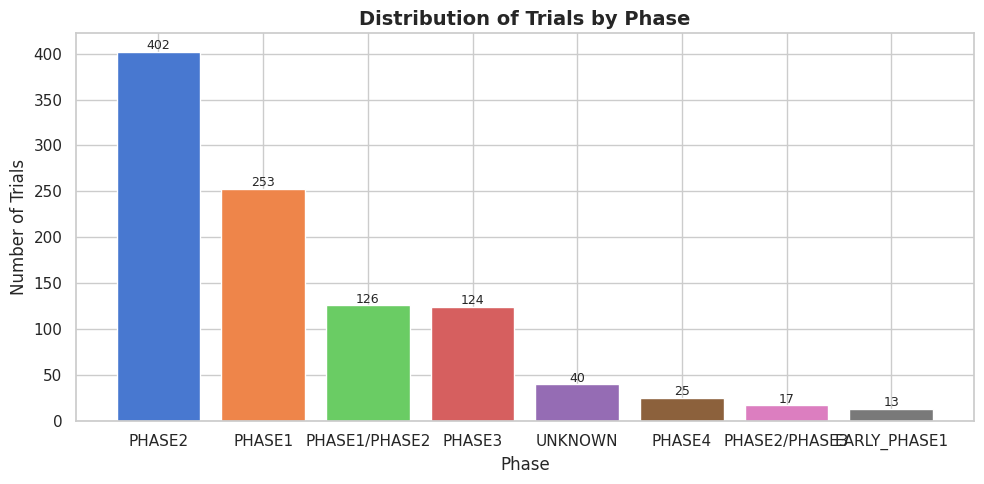

In [25]:
# 8A — PHASE DISTRIBUTION
fig, ax = plt.subplots(figsize=fig_size)

phase_counts = df["phase"].value_counts(dropna=False)
phase_counts.index = phase_counts.index.fillna("UNKNOWN")

bars = ax.bar(phase_counts.index, phase_counts.values, color=sns.color_palette("muted"))
ax.set_title("Distribution of Trials by Phase", fontsize=14, fontweight="bold")
ax.set_xlabel("Phase")
ax.set_ylabel("Number of Trials")

# Add count labels on top of bars
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, 
            bar.get_height() + 3,
            str(int(bar.get_height())),
            ha="center", fontsize=9)

plt.tight_layout()
plt.savefig("phase_distribution.png", dpi=150)
plt.show()

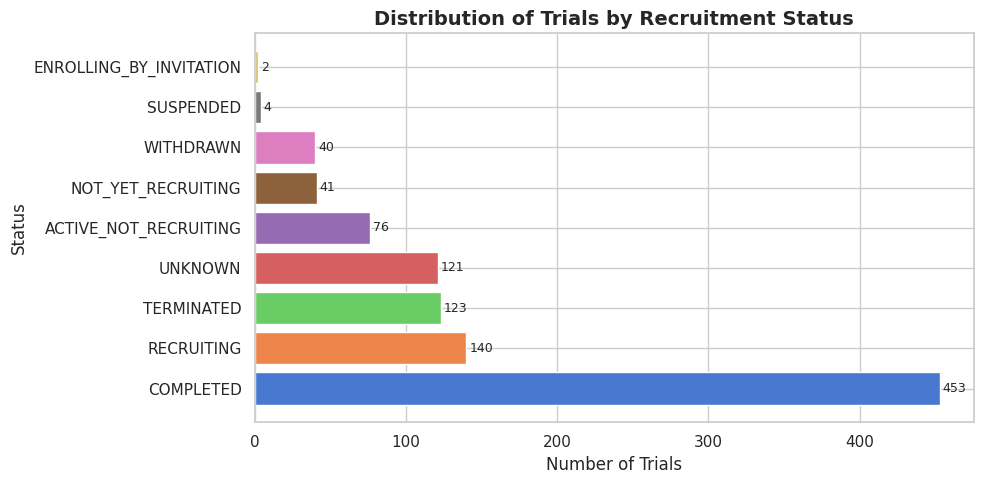

In [26]:
# 8B — RECRUITMENT STATUS DISTRIBUTION
fig, ax = plt.subplots(figsize=fig_size)

status_counts = df["recruitment_status"].value_counts()

bars = ax.barh(status_counts.index, status_counts.values, 
               color=sns.color_palette("muted"))
ax.set_title("Distribution of Trials by Recruitment Status", 
             fontsize=14, fontweight="bold")
ax.set_xlabel("Number of Trials")
ax.set_ylabel("Status")

for bar in bars:
    ax.text(bar.get_width() + 2,
            bar.get_y() + bar.get_height()/2,
            str(int(bar.get_width())),
            va="center", fontsize=9)

plt.tight_layout()
plt.savefig("status_distribution.png", dpi=150)
plt.show()

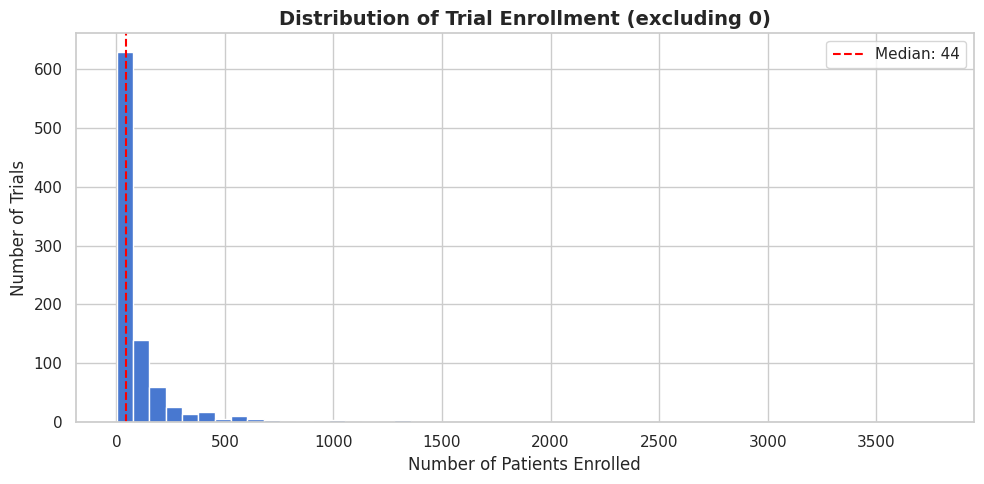

Median enrollment : 44
Mean enrollment   : 122
Max enrollment    : 3762
Min enrollment    : 1


In [27]:
# 8C — ENROLLMENT DISTRIBUTION
fig, ax = plt.subplots(figsize=fig_size)

enrollment_data = df["enrollment"].dropna()
enrollment_data = enrollment_data[enrollment_data > 0]  # exclude zeros

ax.hist(enrollment_data, bins=50, color=sns.color_palette("muted")[0], edgecolor="white")
ax.set_title("Distribution of Trial Enrollment (excluding 0)", 
             fontsize=14, fontweight="bold")
ax.set_xlabel("Number of Patients Enrolled")
ax.set_ylabel("Number of Trials")
ax.axvline(enrollment_data.median(), color="red", linestyle="--", 
           label=f"Median: {enrollment_data.median():.0f}")
ax.legend()

plt.tight_layout()
plt.savefig("enrollment_distribution.png", dpi=150)
plt.show()

print(f"Median enrollment : {enrollment_data.median():.0f}")
print(f"Mean enrollment   : {enrollment_data.mean():.0f}")
print(f"Max enrollment    : {enrollment_data.max():.0f}")
print(f"Min enrollment    : {enrollment_data.min():.0f}")

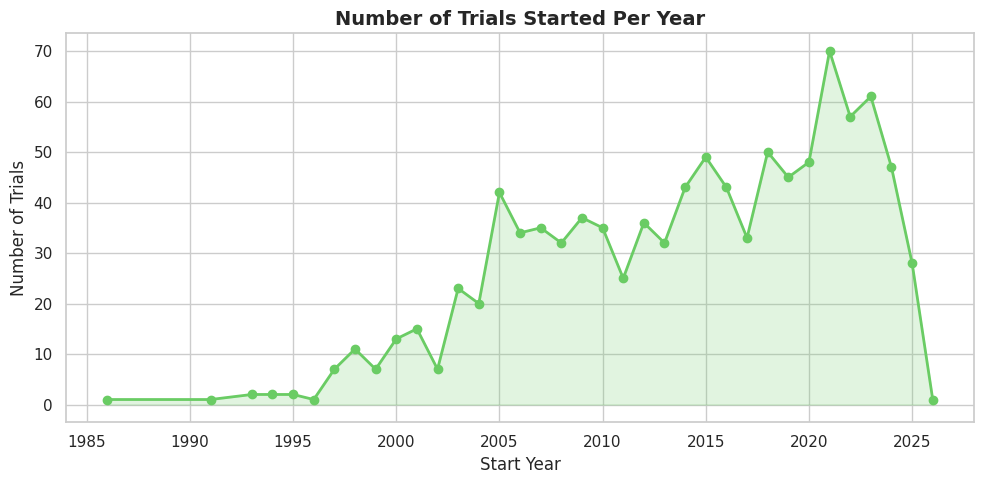

In [28]:
# 8D — TRIALS OVER TIME BY START YEAR
fig, ax = plt.subplots(figsize=fig_size)

df["start_year"] = df["start_date"].dt.year
year_counts = df["start_year"].value_counts().sort_index()

ax.plot(year_counts.index, year_counts.values, 
        marker="o", linewidth=2, 
        color=sns.color_palette("muted")[2])
ax.fill_between(year_counts.index, year_counts.values, alpha=0.2,
                color=sns.color_palette("muted")[2])
ax.set_title("Number of Trials Started Per Year", 
             fontsize=14, fontweight="bold")
ax.set_xlabel("Start Year")
ax.set_ylabel("Number of Trials")

plt.tight_layout()
plt.savefig("trials_over_time.png", dpi=150)
plt.show()

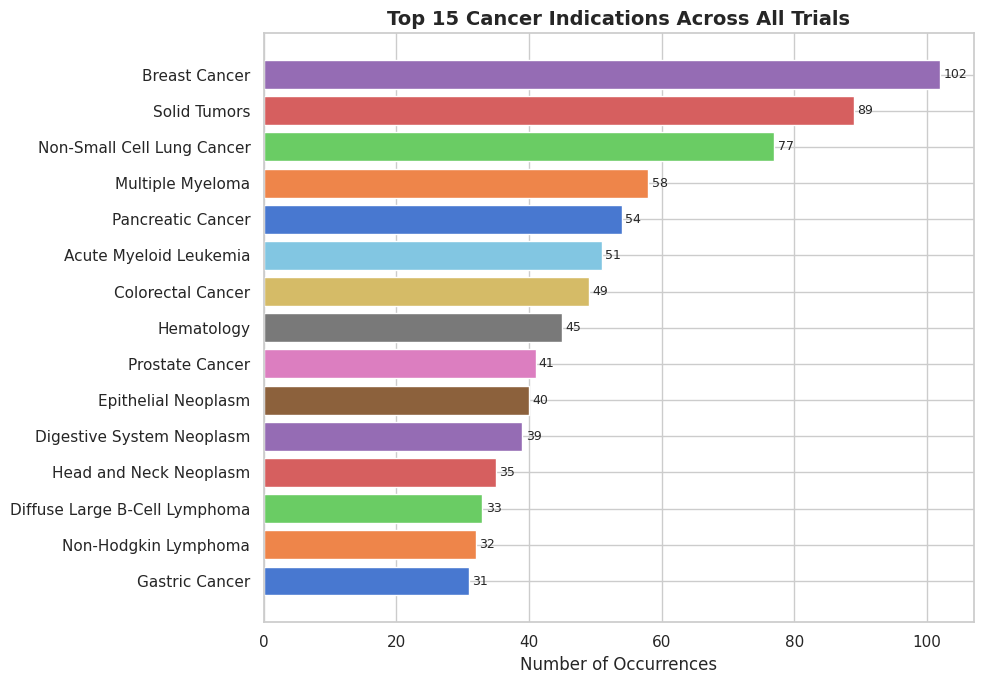

In [29]:
# 8E — TOP 15 INDICATIONS
fig, ax = plt.subplots(figsize=(10, 7))

top_indications = pd.Series(all_indications).value_counts().head(15)

bars = ax.barh(top_indications.index[::-1], 
               top_indications.values[::-1],
               color=sns.color_palette("muted"))
ax.set_title("Top 15 Cancer Indications Across All Trials", 
             fontsize=14, fontweight="bold")
ax.set_xlabel("Number of Occurrences")

for bar in bars:
    ax.text(bar.get_width() + 0.5,
            bar.get_y() + bar.get_height()/2,
            str(int(bar.get_width())),
            va="center", fontsize=9)

plt.tight_layout()
plt.savefig("top_indications.png", dpi=150)
plt.show()

In [30]:
# Full list of unique interventions sorted alphabetically
all_drugs = []
for val in df["interventions_drugs"]:
    try:
        parsed = ast.literal_eval(val)
        all_drugs.extend(parsed)
    except:
        pass

unique_drugs = pd.Series(all_drugs).value_counts()
print(f"Total unique interventions: {len(unique_drugs)}")
print(unique_drugs.to_string())

Total unique interventions: 1014
Cyclophosphamide                                                                                  59
Cisplatin                                                                                         57
Paclitaxel                                                                                        55
Carboplatin                                                                                       55
Gemcitabine                                                                                       48
Placebo Control                                                                                   48
Docetaxel                                                                                         41
Oxaliplatin                                                                                       39
Radiation Therapy                                                                                 37
Fluorouracil                                              